In [43]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
     -O fonts/NanumGothic.ttf

In [44]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [45]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)

N = 150

genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})


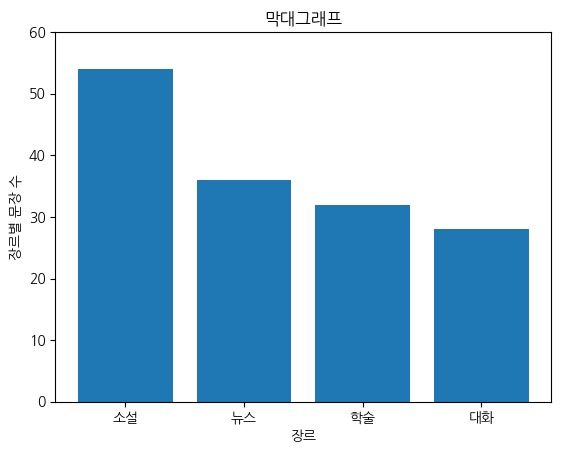

In [46]:
counts=texts["장르"].value_counts()
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set_title("막대그래프")
ax.set_xlabel("장르")
ax.set_ylabel("장르별 문장 수")
ax.set_ylim(0, 60)
plt.show()       

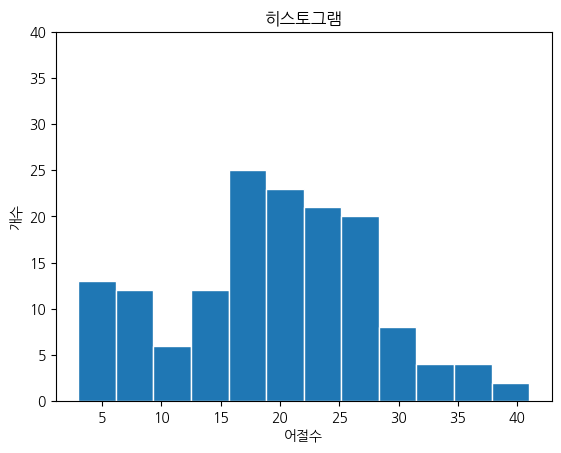

In [47]:
fig, ax = plt.subplots()
ax.hist(texts["어절수"], bins=12, edgecolor='white')
ax.set_title("히스토그램")
ax.set_xlabel("어절수")
ax.set_ylabel("개수")
ax.set_ylim(0, 40)
plt.show() 


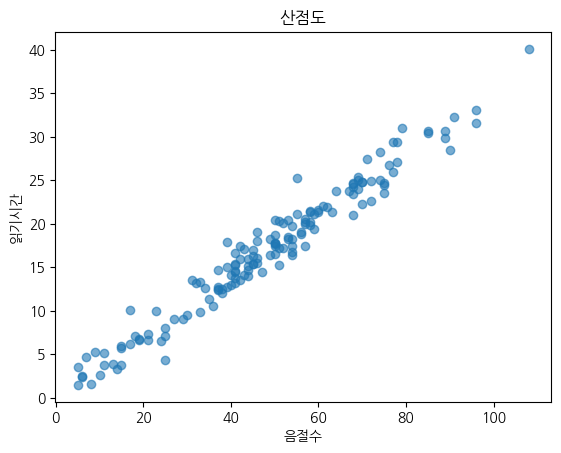

In [48]:
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.6)
ax.set_title('산점도')
ax.set_xlabel('음절수')
ax.set_ylabel('읽기시간')
plt.show()

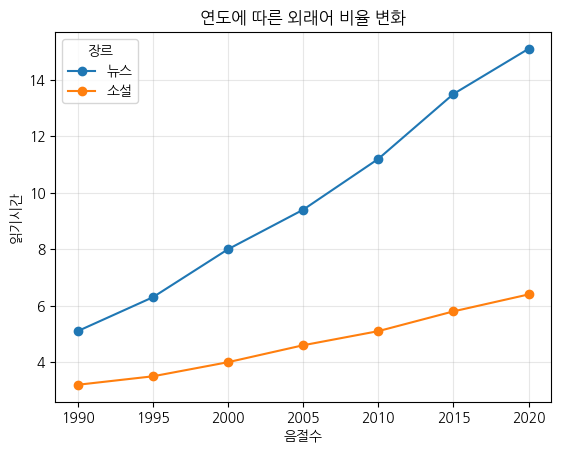

In [49]:
fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker="o", label="뉴스")
ax.plot(trends['연도'], trends['소설'], marker="o", label="소설")
ax.legend(title="장르")
ax.grid(True, alpha=0.3)
ax.set_title('연도에 따른 외래어 비율 변화')
ax.set_xlabel('음절수')
ax.set_ylabel('읽기시간')
plt.show()

두 장르의 외래어 비율을 비교하면 언제나 뉴스에서 소설보다 외래어를 많이 사용했으며, 두 장르에서 외래어 비율이 계속해서 증가해왔다.

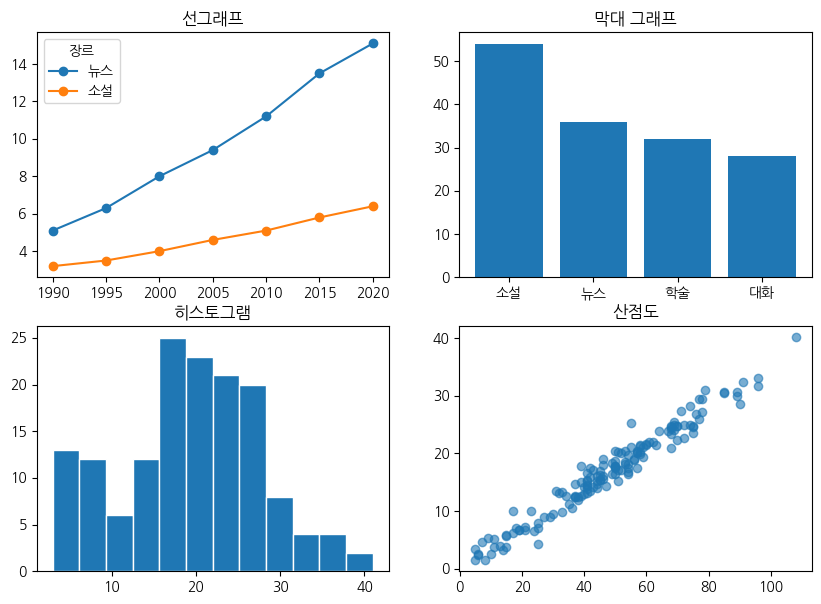

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].plot(trends['연도'], trends['뉴스'], marker="o", label="뉴스")
axes[0, 0].plot(trends['연도'], trends['소설'], marker="o", label="소설")
axes[0, 0].legend(title="장르")
axes[0, 0].set_title("선그래프")
axes[0, 1].bar(counts.index, counts.values)
axes[0, 1].set_title("막대 그래프")
axes[1, 0].hist(texts["어절수"], bins=12, edgecolor='white')
axes[1, 0].set_title("히스토그램")
axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.6)
axes[1, 1].set_title("산점도")
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight') 
plt.show()

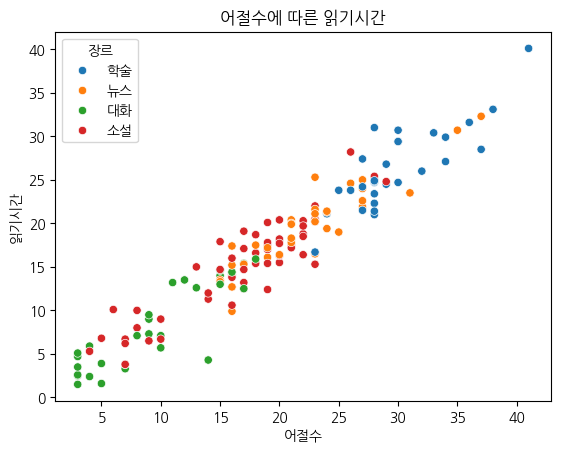

In [51]:
import seaborn as sns

fig, ax = plt.subplots()
sns.scatterplot(
    data=texts,
    x='어절수', y='읽기시간',
    hue='장르', 
    ax=ax, 
)
ax.set_title('어절수에 따른 읽기시간')
plt.show()

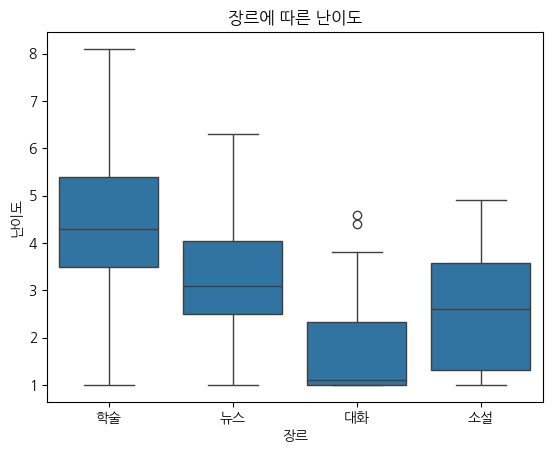

In [52]:
fig, ax = plt.subplots()
sns.boxplot(
    data=texts, 
    x='장르', 
    y='난이도',
    ax=ax)
ax.set_title('장르에 따른 난이도')
plt.show()

가장 난이도가 높은 장르는 학술이라고 할 수 있으며, 퍼짐(상자의 크기)이 가장 큰 장르는 소설이다.

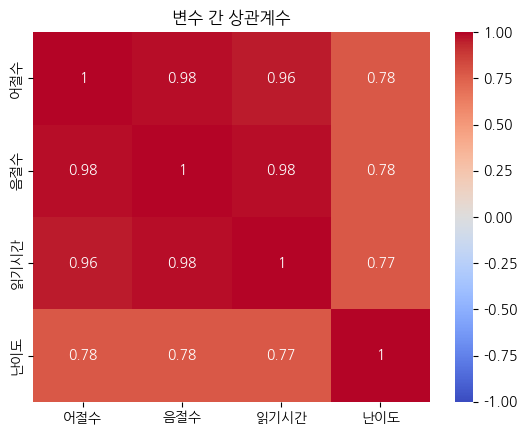

In [53]:
fig, ax = plt.subplots()
corr=texts[["어절수", "음절수", "읽기시간", "난이도"]].corr()
sns.heatmap(corr, annot=True, 
            cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax)
ax.set_title('변수 간 상관계수')
plt.show()

음절수와 어절수, 음절수와 읽기시간, 어절수와 읽기시간이 함께 증가한다. 음절수가 많으면 어절수도 늘고, 어절수가 늘면 자주 끊어읽게 되어 읽는 시간 또한 증가하기 때문이다. 

<Axes: xlabel='장르', ylabel='난이도'>

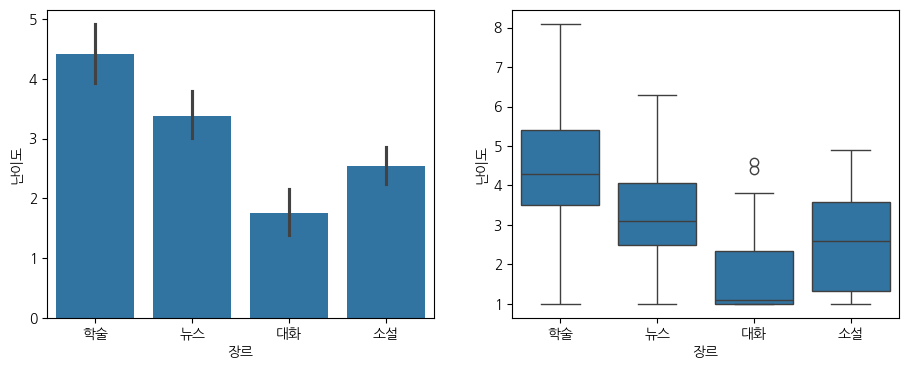

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])

왼쪽의 자료는 각 장르의 난이도 평균을 보여주지만 오른쪽 자료와는 달리 평균이 아닌 값들의 "분포"를 보여주지 않는다. 뉴스와 소설의 난이도 평균은 비슷해 보이지만 실제로 그 값들의 분포에는 오른쪽 그래프에서 볼 수 있듯이 차이가 있다.

(0.0, 30.0)

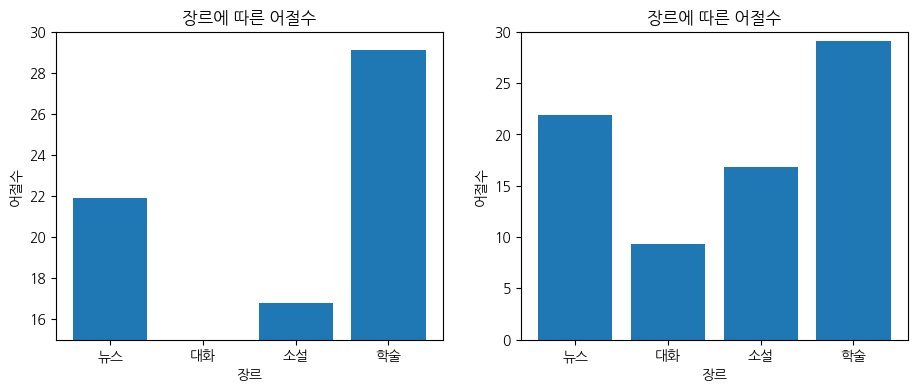

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mean=texts.groupby("장르")["어절수"].mean()
axes[0].bar(mean.index, mean.values)
axes[0].set_title("장르에 따른 어절수")
axes[0].set_xlabel("장르")
axes[0].set_ylabel("어절수")
axes[0].set_ylim(15, 30)

axes[1].bar(mean.index, mean.values)
axes[1].set_title("장르에 따른 어절수")
axes[1].set_xlabel("장르")
axes[1].set_ylabel("어절수")
axes[1].set_ylim(0, 30)


In [ ]:
y값을 0부터 그리지 않은 오른쪽 막대 그래프의 경우엔 대화의 어절 수가 잘려 나타나지 않으며, 실제보다 뉴스와 소설의 어절수 차이가 큰 것처럼 보인다. 